
Original DataFrame:

   Student_name  Semester  Marks   Age  Height  Study_Hours
0         Aisha       1.0   75.0  19.0   160.0          3.0
1         Kabir       2.0   82.0  20.0   172.0          4.0
2         Meera       3.0    NaN   NaN   168.0          5.0
3         Rohan       2.0   90.0  21.0     NaN          NaN
4          Isha       NaN   88.0  20.0   165.0          6.0
5           Dev       4.0   76.0  22.0   174.0          3.0
6          Nina       3.0   84.0  21.0   170.0          4.0
7        Aditya       1.0    NaN   NaN   169.0          5.0
8          Sara       2.0   79.0  23.0     NaN          NaN
9         Kunal       NaN   91.0  24.0   176.0          7.0
10        Aryan       5.0   87.0  22.0   173.0          6.0

Missing Values in each column:

Student_name    0
Semester        2
Marks           2
Age             2
Height          2
Study_Hours     2
dtype: int64

Semester Value Counts:

Semester
2.0    3
1.0    2
3.0    2
4.0    1
5.0    1
Name: count, dtype: int64

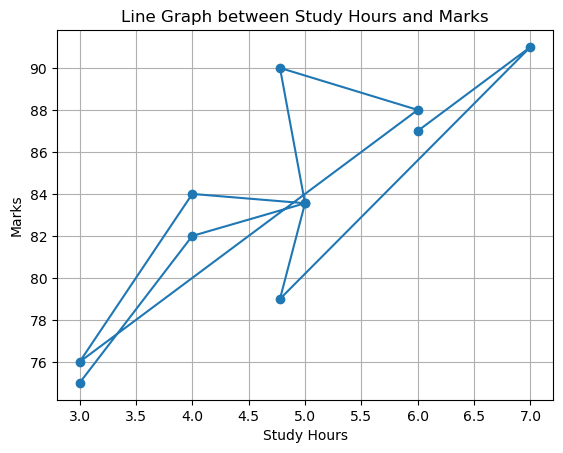


Correlation between marks and study hours: 0.8405226895152444

IQR Outliers:

Empty DataFrame
Columns: [Student_name, Semester, Marks, Age, Height, Study_Hours]
Index: []

Z-score Outliers:

Empty DataFrame
Columns: [Student_name, Semester, Marks, Age, Height, Study_Hours, Z_score_Marks]
Index: []


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Create dataset with some null values
data = {
    "Student_name": ['Aisha','Kabir','Meera','Rohan','Isha','Dev','Nina','Aditya','Sara','Kunal','Aryan'],
    "Semester": [1,2,3,2,None,4,3,1,2,None,5],
    "Marks": [75,82,None,90,88,76,84,None,79,91,87],
    "Age": [19,20,None,21,20,22,21,None,23,24,22],
    "Height": [160,172,168,None,165,174,170,169,None,176,173],
    "Study_Hours": [3,4,5,None,6,3,4,5,None,7,6]
}

df = pd.DataFrame(data)

print("\nOriginal DataFrame:\n")
print(df)

# Check missing values
print("\nMissing Values in each column:\n")
print(df.isnull().sum())

# (i) Value count of students in semester
print("\nSemester Value Counts:\n")
print(df["Semester"].value_counts())

# Fill missing numeric values using mean
df.fillna(df.mean(numeric_only=True), inplace=True)

print("\nDataFrame after filling null values:\n")
print(df)

# (iv) Line graph between Study Hours and Marks
plt.plot(df["Study_Hours"], df["Marks"], marker='o')
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Line Graph between Study Hours and Marks")
plt.grid(True)
plt.show()

# (iii) Correlation between Marks and Study Hours
correlation = df["Marks"].corr(df["Study_Hours"])
print("\nCorrelation between marks and study hours:", correlation)

# (ii) Outlier detection using IQR
Q1 = df["Marks"].quantile(0.25)
Q3 = df["Marks"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = df[(df["Marks"] < lower_bound) | (df["Marks"] > upper_bound)]

print("\nIQR Outliers:\n")
print(iqr_outliers)

# Outlier detection using Z-score
df["Z_score_Marks"] = stats.zscore(df["Marks"])

zscore_outliers = df[df["Z_score_Marks"].abs() > 3]

print("\nZ-score Outliers:\n")
print(zscore_outliers)